In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt

# Preprocesado y modelo
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("iris.csv")
df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [3]:
datos = df.iloc[:, 0:4]
datos

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [4]:
datos_estandarizados = StandardScaler().fit_transform(datos)
datos_estandarizados

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [5]:
# Número de filas de la base de datos
renglones = len(datos.index)
renglones

150

In [6]:
# Matriz de correlaciones
A = (1/renglones) * np.dot(datos_estandarizados.T, datos_estandarizados)
A

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [7]:
# Modelo PCA
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(datos)

# Extraemos el modelo PCA
modelo_pca = pca_pipe.named_steps['pca']

# Eigenvalores
print("Eigenvalores:")
resultados = LA.eigvals(A)
print(resultados)

Eigenvalores:
[2.91849782 0.91403047 0.14675688 0.02071484]


In [8]:
# Porcentaje de varianza explicada por cada componente
print("Porcentaje de varianza explicada por componente:")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente:
[0.72962445 0.22850762 0.03668922 0.00517871]


In [9]:
# Eigenvectores
print("Eigenvectores:")

pd.DataFrame(
    data=modelo_pca.components_,
    columns=datos.columns,
    index=['PC1', 'PC2', 'PC3', 'PC4']
)

Eigenvectores:


,sepal.length,sepal.width,petal.length,petal.width
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942
PC3,0.719566,-0.244382,-0.142126,-0.634273
PC4,-0.261286,0.123510,0.801449,-0.523597


In [10]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, datos_estandarizados.T)

proyecciones = pd.DataFrame(
    proyecciones,
    index=['PC1', 'PC2', 'PC3', 'PC4']
)

proyecciones = proyecciones.transpose()
proyecciones

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


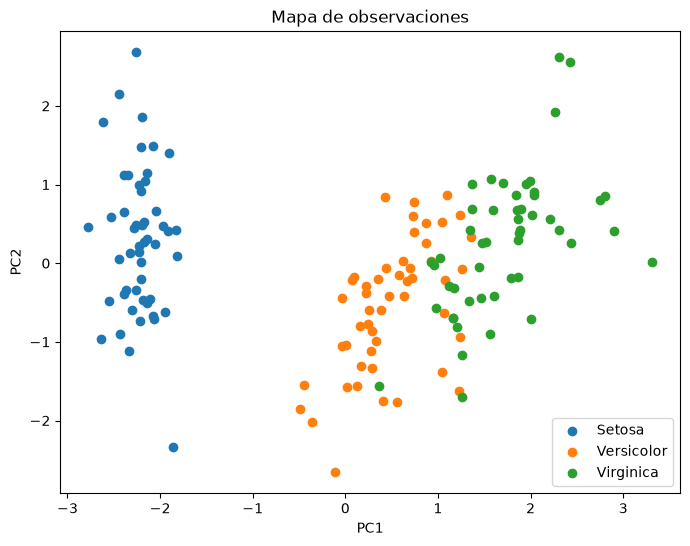

In [11]:
# Mapa de observaciones
plt.figure(figsize=(8,6))

for especie in df['variety'].unique():
    grupo = proyecciones[df['variety'] == especie]
    plt.scatter(grupo['PC1'], grupo['PC2'], label=especie)

plt.title("Mapa de observaciones")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [12]:
# Datos para el mapa de factores
componentes_2 = pd.DataFrame(
    data=modelo_pca.components_,
    columns=datos.columns,
    index=['PC1', 'PC2', 'PC3', 'PC4']
)

componentes_2 = componentes_2.iloc[0:2, :]
componentes_2 = componentes_2.T

componentes_2

,PC1,PC2
sepal.length,0.521066,0.377418
sepal.width,-0.269347,0.923296
petal.length,0.580413,0.024492
petal.width,0.564857,0.066942


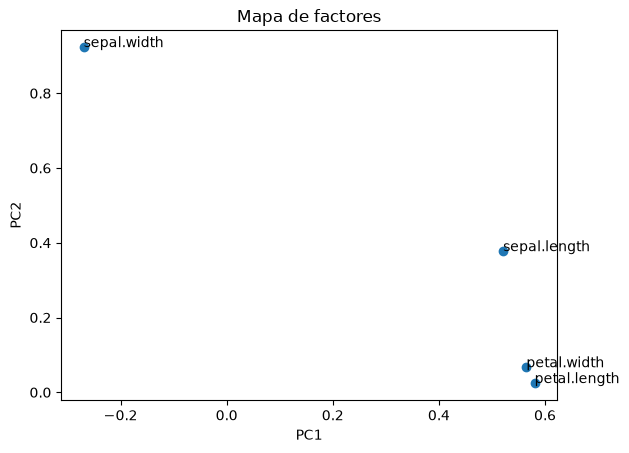

In [13]:
# Mapa de factores
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index

x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()

ax.set_title("Mapa de factores")
ax.scatter(x, y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [14]:
# Casos específicos del DataFrame
df.loc[[0, 50, 100]]

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
50,7.0,3.2,4.7,1.4,Versicolor
100,6.3,3.3,6.0,2.5,Virginica
